In [ ]:
# Install necessary visualization libraries
!pip install kagglehub pandas matplotlib seaborn

import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Download the dataset
print("Downloading SEP-28k...")
dataset_path = kagglehub.dataset_download("ikrbasak/sep-28k")
print("Path to dataset files:", dataset_path)

# 2. Load the CSV
csv_path = os.path.join(dataset_path, "SEP-28k_labels.csv")
df = pd.read_csv(csv_path)

# 3. Construct the 'Name' identifier
df['Name'] = df['Show'].astype(str) + '_' + df['EpId'].astype(str) + '_' + df['ClipId'].astype(str)

print(f"\nTotal audio clips in dataset: {len(df)}")
df.head()

Using Colab cache for faster access to the 'sep-28k' dataset.
Path to dataset files: /kaggle/input/sep-28k

Total audio clips in dataset: 28177


,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech,Name
0,HeStutters,0,0,31900320,31948320,0,0,0,0,0,0,0,0,3,1,0,0,HeStutters_0_0
1,HeStutters,0,1,31977120,32025120,0,0,0,0,0,0,0,0,3,1,0,0,HeStutters_0_1
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,0,0,0,3,0,0,0,HeStutters_0_2
3,HeStutters,0,3,35200640,35248640,0,0,1,0,0,0,0,0,2,0,0,0,HeStutters_0_3
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,0,0,0,3,0,0,0,HeStutters_0_4


In [ ]:
# Define the core stuttering classes
classes = ['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection']

# Create new binary columns (1 if >= 2 annotators agreed, 0 otherwise)
for c in classes:
    df[f'{c}_binary'] = (df[c] >= 2).astype(int)

# Create a 'Fluent' class: If NO stutters were confidently detected, mark as fluent
df['Fluent'] = (df[[f'{c}_binary' for c in classes]].sum(axis=1) == 0).astype(int)

print("Label processing complete. Ready for visualization.")

Label processing complete. Ready for visualization.


/tmp/ipython-input-559772370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


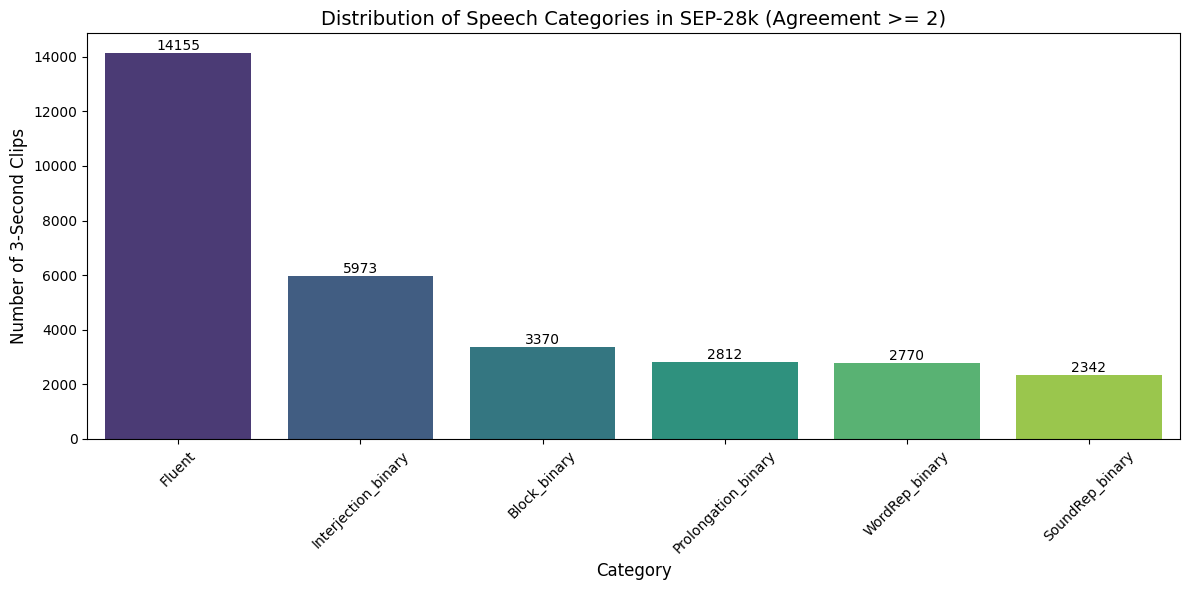

In [ ]:
# Count the occurrences of each class
class_counts = df[[f'{c}_binary' for c in classes] + ['Fluent']].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

plt.title('Distribution of Speech Categories in SEP-28k (Agreement >= 2)', fontsize=14)
plt.ylabel('Number of 3-Second Clips', fontsize=12)
plt.xlabel('Category', fontsize=12)

# Add the exact numbers on top of the bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

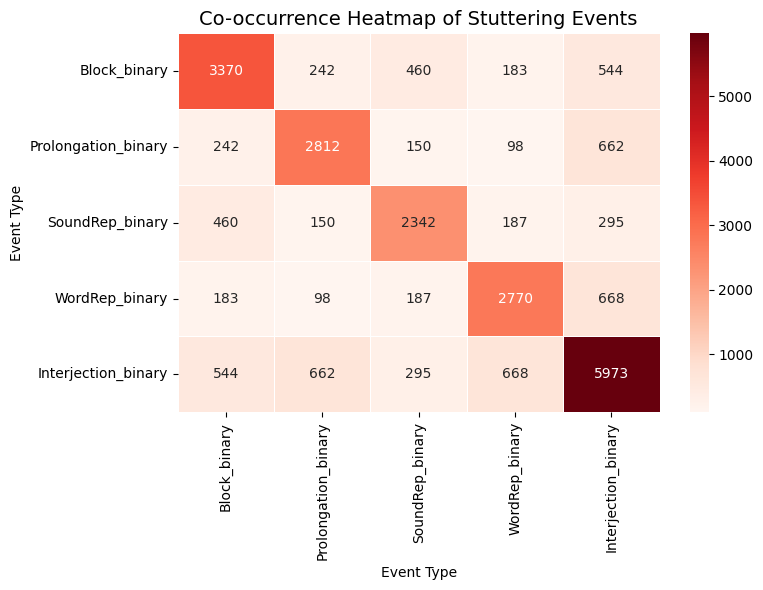

In [ ]:
# Create a matrix of just the binary stutter labels
stutter_matrix = df[[f'{c}_binary' for c in classes]]

# Calculate the co-occurrence (Dot product of the matrix with its transpose)
co_occurrence = stutter_matrix.T.dot(stutter_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Reds', linewidths=.5)

plt.title('Co-occurrence Heatmap of Stuttering Events', fontsize=14)
plt.ylabel('Event Type')
plt.xlabel('Event Type')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2966024176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=show_counts.index, x=show_counts.values, palette='magma')


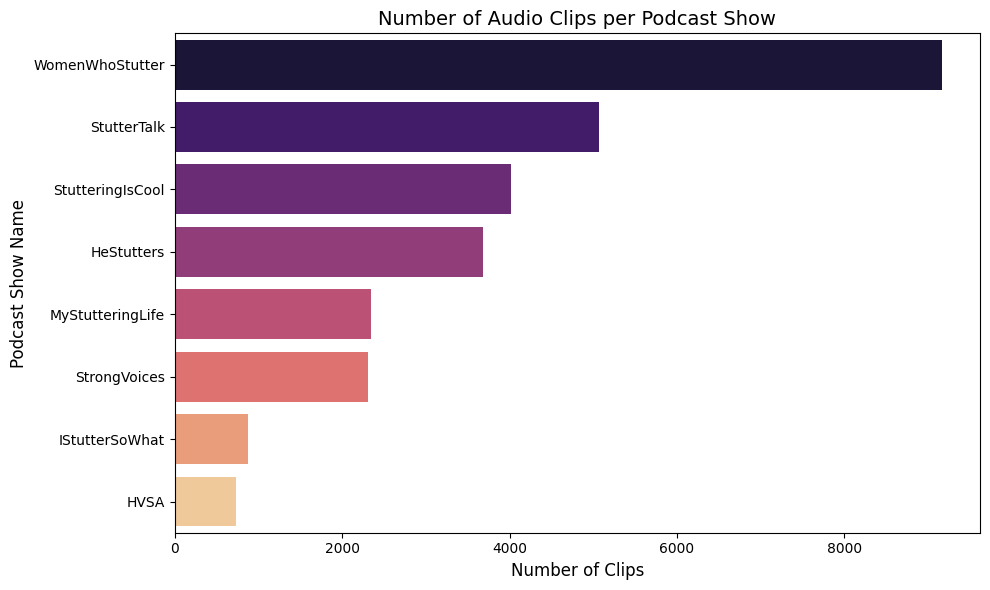

In [ ]:
plt.figure(figsize=(10, 6))
# Count clips per show
show_counts = df['Show'].value_counts()

sns.barplot(y=show_counts.index, x=show_counts.values, palette='magma')

plt.title('Number of Audio Clips per Podcast Show', fontsize=14)
plt.xlabel('Number of Clips', fontsize=12)
plt.ylabel('Podcast Show Name', fontsize=12)
plt.tight_layout()
plt.show()